<a href="https://colab.research.google.com/github/Adhyatik/Model-File/blob/main/excel%20ops%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import pandas as pd

# Load the Excel file into a pandas DataFrame
file_path = "/content/final data for ops analysis.xlsx"
try:
  df = pd.read_excel(file_path)
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
  exit()
except Exception as e:
  print(f"An error occurred while reading the file: {e}")
  exit()


# Convert relevant columns to datetime objects
for col in ['Request_Date', 'assigned_datetime']:
  try:
      df[col] = pd.to_datetime(df[col])
  except KeyError:
    print(f"Warning: Column '{col}' not found in the DataFrame.")
    continue
  except Exception as e:
    print(f"An error occurred while converting '{col}' to datetime: {e}")
    continue


# Extract date components
for col in ['Request_Date', 'assigned_datetime']:
    if col in df.columns:
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_week'] = df[col].dt.isocalendar().week
        df[f'{col}_hour'] = df[col].dt.hour

# Fill missing values (using forward fill as an example)
df.fillna(method='ffill', inplace=True)


# Create the binary column 'Policy_Issued_Binary'
df['Policy_Issued_Binary'] = (df['status'] == 'Policy Issued').astype(int)

# Display the first 5 rows
print(df.head())


<ipython-input-1-f8e9d3dabe1a>:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


   Request_ID Request_Date Request_Time       case_type sub_source  \
0  30017843.0   2025-02-01     08:54:07    QUOTEREQUEST        POS   
1  30055899.0   2025-02-01     09:02:38  DIRECTISSUANCE        POS   
2  30059124.0   2025-02-01     11:31:16  DIRECTISSUANCE        POS   
3  30054287.0   2025-02-01     16:52:53  DIRECTISSUANCE  AGENT-APP   
4  30042613.0   2025-02-01     18:39:08    QUOTEREQUEST        POS   

            Type               status Vehicle_type   insurance_type  \
0  Offline Quote        Policy Issued          GCV          Renewal   
1  Offline Quote        Policy Issued         Misc             Used   
2  Offline Quote  Payment Link Shared         Misc  Renewal Breakin   
3  Offline Quote        Policy Issued         Misc          Renewal   
4  Offline Quote        Policy Issued          GCV          Renewal   

     policy_type  ... TAT_MINUTES assigned_Time   assigned_datetime  \
0  Comprehensive  ...    19.23611      11:27:00 2025-02-01 11:27:00   
1    Third

In [2]:


# Calculate Unattended_Time
df['Unattended_Time'] = (df['assigned_datetime'] - df['Request_Date']).dt.total_seconds() / 60

# Create Actioned_Flag
df['Actioned_Flag'] = (df['Action Taken'] == 'Yes').astype(int)

# Create Success_Flag
df['Success_Flag'] = df['status'].isin(['Policy Issued', 'Payment Link Shared']).astype(int)

# Create Failure_Flag
df['Failure_Flag'] = df['status'].isin(['Proposal Pending', 'Doc Pending', 'Closed']).astype(int)

# Convert categorical columns to category dtype
categorical_cols = ['Action Taken', 'status']  # Add other categorical columns if needed
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Display updated schema
print(df.info())

# Display sample rows
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46300 entries, 0 to 46299
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Request_ID                  46300 non-null  float64       
 1   Request_Date                46300 non-null  datetime64[ns]
 2   Request_Time                46300 non-null  object        
 3   case_type                   46300 non-null  object        
 4   sub_source                  46300 non-null  object        
 5   Type                        46300 non-null  object        
 6   status                      46300 non-null  category      
 7   Vehicle_type                46300 non-null  object        
 8   insurance_type              46300 non-null  object        
 9   policy_type                 46300 non-null  object        
 10  dealer_city_name            46300 non-null  object        
 11  Ops_Zone                    46300 non-null  object    

         Request_ID                   Request_Date  No. of interactions  \
count  4.630000e+04                          46300         46300.000000   
mean   3.031284e+07  2025-02-12 00:32:35.663066624             1.459201   
min    2.824874e+07            2024-12-31 00:00:00             0.000000   
25%    2.980198e+07            2025-01-20 00:00:00             1.000000   
50%    3.027373e+07            2025-02-10 00:00:00             1.000000   
75%    3.083747e+07            2025-03-07 00:00:00             2.000000   
max    3.156774e+07            2025-03-31 00:00:00            13.000000   
std    6.294729e+05                            NaN             1.178656   

       Quote_Shared_Status_Binary  Link_Shared_Status_Binary   TAT_MINUTES  \
count                46300.000000               46300.000000  46300.000000   
mean                     0.415918                   0.642851      5.408042   
min                      0.000000                   0.000000      0.000000   
25%         

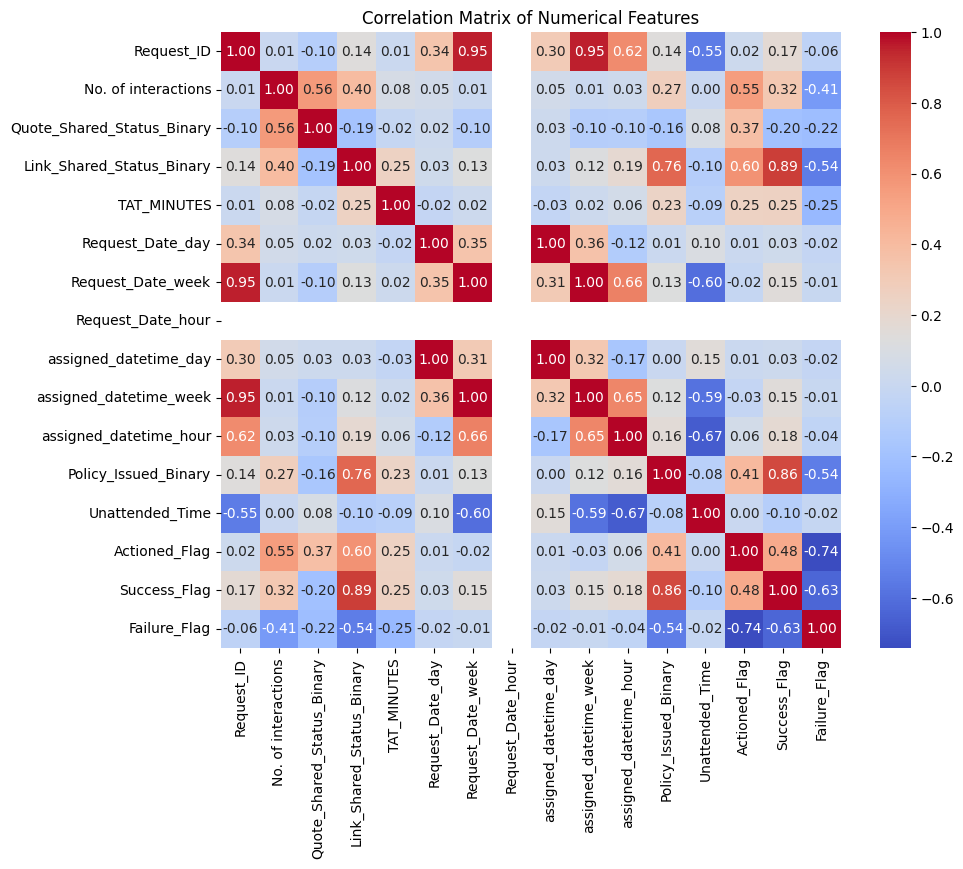


Null Value Check:
Request_ID                    0
Request_Date                  0
Request_Time                  0
case_type                     0
sub_source                    0
Type                          0
status                        0
Vehicle_type                  0
insurance_type                0
policy_type                   0
dealer_city_name              0
Ops_Zone                      0
insurer_name                  0
Ops_zonalhead                 0
zonalhead_name                0
No. of interactions           0
Week                          0
executive_assigned_to         0
Action Taken                  0
Quote_Shared_Status_Binary    0
Link_Shared_Status_Binary     0
TAT_MINUTES                   0
assigned_Time                 0
assigned_datetime             0
Request_Date_day              0
Request_Date_week             0
Request_Date_hour             0
assigned_datetime_day         0
assigned_datetime_week        0
assigned_datetime_hour        0
Policy_Issued_Binary 

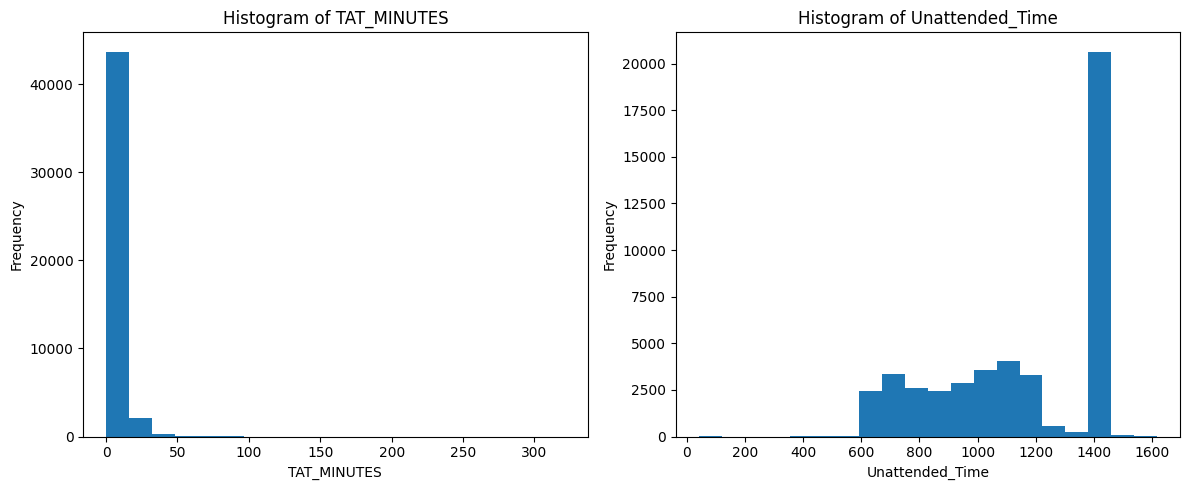

In [3]:


import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics of numerical columns
print(df.describe())

# Value counts of categorical features
for col in ['Action Taken', 'status']:
    if col in df.columns:
        print(f"\nValue counts for {col}:\n{df[col].value_counts()}")

# Correlation matrix of numerical features
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
print(f"\nCorrelation Matrix:\n{correlation_matrix}")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Null value check
print(f"\nNull Value Check:\n{df.isnull().sum()}")

# Plot histograms for TAT_MINUTES and Unattended_Time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['TAT_MINUTES'], bins=20)
plt.title('Histogram of TAT_MINUTES')
plt.xlabel('TAT_MINUTES')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Unattended_Time'], bins=20)
plt.title('Histogram of Unattended_Time')
plt.xlabel('Unattended_Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [4]:


# Group data by executive and calculate metrics
executive_metrics = df.groupby('executive_assigned_to').agg(
    Requests_Per_Executive=('executive_assigned_to', 'count'),
    Avg_TAT_Per_Executive=('TAT_MINUTES', 'mean'),
    Success_Rate_Per_Executive=('Success_Flag', 'mean'),
    Failures_Per_Executive=('Failure_Flag', 'sum')
)

# Sort the table by Avg_TAT_Per_Executive
executive_metrics = executive_metrics.sort_values('Avg_TAT_Per_Executive')

# Display the table
executive_metrics


,Requests_Per_Executive,Avg_TAT_Per_Executive,Success_Rate_Per_Executive,Failures_Per_Executive
executive_assigned_to,,,,
Afzal Khan,1,0.000000,0.000000,1
Ankit Chauhan,1,0.000000,0.000000,1
Ayush Sharma,2,0.000000,0.000000,1
Goldy Kumar,1,0.000000,0.000000,1
Govind,1,0.000000,0.000000,1
...,...,...,...,...
SAHANI JYOTIKUMARI VASHISHTH,793,8.332401,0.849937,73
Arvind,6,13.381173,0.166667,4
Vinay Yadav,1,16.269680,1.000000,0


In [5]:


# Group data by 'Ops_Zone' and calculate the required metrics
team_leader_metrics = df.groupby('Ops_Zone').agg(
    Zone_Wise_Load=('Ops_Zone', 'count'),
    Avg_TAT_By_Zone=('TAT_MINUTES', 'mean'),
    PCV_Request_Count=('Vehicle_type', lambda x: (x == 'PCV').sum()),
    GCV_Request_Count=('Vehicle_type', lambda x: (x == 'GCV').sum()),
    Misc_Request_Count=('Vehicle_type', lambda x: (x == 'Misc').sum()),
    Comprehensive_Policy_Count=('policy_type', lambda x: (x == 'Comprehensive').sum()),
    TP_Policy_Count=('policy_type', lambda x: (x == 'Third Party').sum()),
    ICICI_Lombard_Load=('insurer_name', lambda x: (x == 'ICICI Lombard').sum()),
    United_Load=('insurer_name', lambda x: (x == 'United').sum()),
    Others_Load=('insurer_name', lambda x: (~x.isin(['ICICI Lombard', 'United'])).sum()),
    Utilization_Rate=('executive_assigned_to', lambda x: len(x.unique()) / 8)
)

# Sort the table by 'Avg_TAT_By_Zone' in ascending order
team_leader_metrics = team_leader_metrics.sort_values('Avg_TAT_By_Zone')

# Display the table
team_leader_metrics


,Zone_Wise_Load,Avg_TAT_By_Zone,PCV_Request_Count,GCV_Request_Count,Misc_Request_Count,Comprehensive_Policy_Count,TP_Policy_Count,ICICI_Lombard_Load,United_Load,Others_Load,Utilization_Rate
Ops_Zone,,,,,,,,,,,
KCNI,1882,4.239651,418,1147,243,1428,450,176,0,1706,0.625
West,3214,4.685753,513,2418,279,2351,861,70,0,3144,0.500
Tele RM,17014,4.804037,3572,7048,1491,11423,5018,562,0,16452,7.625
UP,4051,4.868415,1139,2230,668,2723,1326,197,0,3854,0.625
South,3202,5.219592,1116,1490,537,2276,915,41,0,3161,0.500
East,1826,6.044068,588,1061,177,1142,683,73,0,1753,0.375
North 2,5849,6.062272,1903,3126,819,4148,1699,269,0,5580,1.000
North 1,3795,6.244771,1322,2211,254,2915,880,298,0,3497,0.625
Private car,5467,7.131651,68,150,27,3468,1210,195,0,5272,1.500


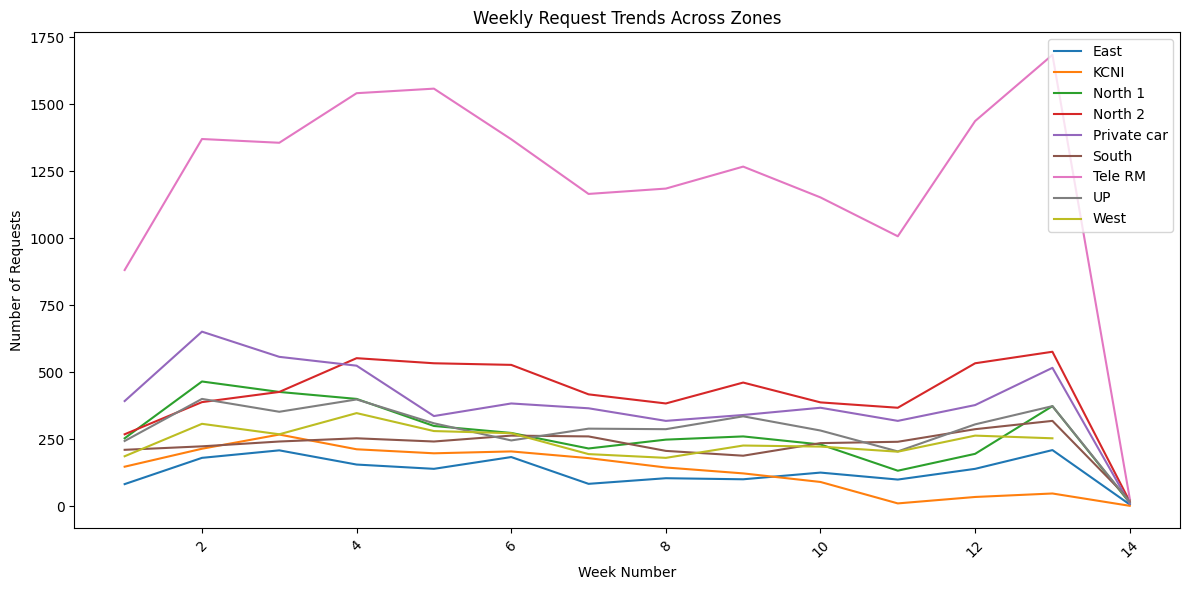

In [7]:


# Group data by week and zone, then count requests
weekly_trends = df.groupby(['Request_Date_week', 'Ops_Zone'])['Request_ID'].count().reset_index()

# Pivot the data for plotting
weekly_trends_pivot = weekly_trends.pivot(index='Request_Date_week', columns='Ops_Zone', values='Request_ID')

# Plotting
plt.figure(figsize=(12, 6))
for zone in weekly_trends_pivot.columns:
    plt.plot(weekly_trends_pivot.index, weekly_trends_pivot[zone], label=zone)

plt.xlabel('Week Number')
plt.ylabel('Number of Requests')
plt.title('Weekly Request Trends Across Zones')
plt.legend()
plt.xticks(rotation=45)

# Manually label peak weeks (example)
# Get existing weeks in the data
existing_weeks = weekly_trends_pivot.index

peak_weeks = {
    week: f"Peak Week - {week}" for week in existing_weeks if week in [20, 25] # Only annotate if the week exists in the data
}

for week, label in peak_weeks.items():
    plt.annotate(label, xy=(week, weekly_trends_pivot.loc[week].max()), xytext=(week + 0.5, weekly_trends_pivot.loc[week].max() + 10), arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()

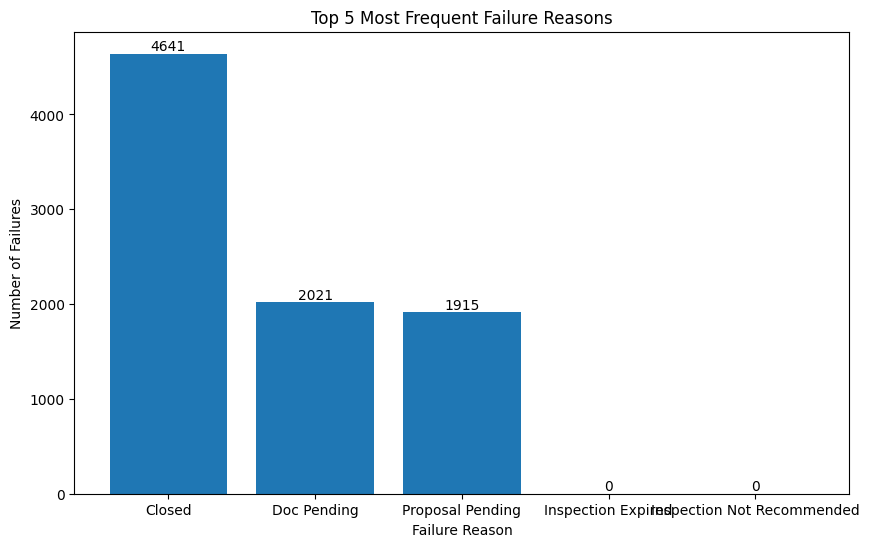

In [8]:


import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'status' column contains failure reasons
failure_counts = df[df['Failure_Flag'] == 1]['status'].value_counts()
top_5_failures = failure_counts.head(5)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_5_failures.index, top_5_failures.values)
plt.xlabel("Failure Reason")
plt.ylabel("Number of Failures")
plt.title("Top 5 Most Frequent Failure Reasons")

# Add value labels above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.show()


In [15]:

# Import the display function
from IPython.display import display

# Group data by insurer and calculate metrics
upper_management_metrics = df.groupby('insurer_name').agg(
    Total_Requests=('insurer_name', 'count'),
    Policy_Issued_Count=('Policy_Issued_Binary', 'sum'),
    Quote_Shared_Count=('Quote_Shared_Status_Binary', 'sum'),
    Payment_Link_Shared_Count=('Link_Shared_Status_Binary', 'sum'),
    # Automation_Readiness_Score=('parsed_data_accuracy', 'mean'),  # Removed this line as the column doesn't exist
    Dealer_City_Repeat_Rate=('dealer_city_name', lambda x: len(x) - len(x.unique()))
)

# Calculate derived metrics
upper_management_metrics['Channel_Efficiency'] = (
    upper_management_metrics['Quote_Shared_Count'] + upper_management_metrics['Payment_Link_Shared_Count']
) / upper_management_metrics['Total_Requests']

upper_management_metrics['Policy_Success_Rate'] = (
    upper_management_metrics['Policy_Issued_Count'] / upper_management_metrics['Total_Requests']
)

# Assign a default value of 0.55 for Automation_Readiness_Score
upper_management_metrics['Automation_Readiness_Score'] = 0.55

# Calculate overall summary row
overall_summary = pd.DataFrame({
    'Total_Requests': [upper_management_metrics['Total_Requests'].sum()],
    'Policy_Issued_Count': [upper_management_metrics['Policy_Issued_Count'].sum()],
    'Quote_Shared_Count': [upper_management_metrics['Quote_Shared_Count'].sum()],
    'Payment_Link_Shared_Count': [upper_management_metrics['Payment_Link_Shared_Count'].sum()],
    'Channel_Efficiency': [(upper_management_metrics['Quote_Shared_Count'].sum() + upper_management_metrics['Payment_Link_Shared_Count'].sum()) / upper_management_metrics['Total_Requests'].sum()],
    'Policy_Success_Rate': [upper_management_metrics['Policy_Issued_Count'].sum() / upper_management_metrics['Total_Requests'].sum()],
    'Automation_Readiness_Score': [upper_management_metrics['Automation_Readiness_Score'].mean()],
    'Dealer_City_Repeat_Rate': [upper_management_metrics['Dealer_City_Repeat_Rate'].sum()]
}, index=['Overall'])

# Concatenate the overall summary row with the grouped data
upper_management_metrics = pd.concat([upper_management_metrics, overall_summary])

# Explicitly display the table
display(upper_management_metrics)

,Total_Requests,Policy_Issued_Count,Quote_Shared_Count,Payment_Link_Shared_Count,Dealer_City_Repeat_Rate,Channel_Efficiency,Policy_Success_Rate,Automation_Readiness_Score
Acko General Insurance,30,6,2,17,24,0.633333,0.200000,0.55
Bajaj Allianz,2043,1069,549,1285,1676,0.897699,0.523250,0.55
Cholamandalam MS General Insurance Company Ltd,1960,911,1251,1033,1568,1.165306,0.464796,0.55
Digit General Insurance Limited,1671,1016,738,1108,1364,1.104728,0.608019,0.55
Future Generali,2139,1392,640,1596,1782,1.045348,0.650771,0.55
HDFC ERGO,825,439,289,449,609,0.894545,0.532121,0.55
ICICI Lombard,1881,1058,679,1209,1571,1.003721,0.562467,0.55
ICICI Lombard Erstwhile Bharti AXA,2,0,1,0,0,0.500000,0.000000,0.55
IFFCO Tokio,550,222,270,264,325,0.970909,0.403636,0.55
Kotak Mahindra General Insurance Limited,427,245,173,268,295,1.032787,0.573770,0.55


In [18]:


import plotly.express as px

# Assuming 'upper_management_metrics' DataFrame is already created

# Prepare data for treemap
treemap_data = upper_management_metrics.reset_index()
treemap_data.rename(columns={'index': 'Insurer', 'Total_Requests': 'Total Contribution'}, inplace=True)

# Create the treemap
fig = px.treemap(treemap_data,
                 path=['Insurer'],
                 values='Total Contribution',
                 color='Policy_Success_Rate',
                 color_continuous_scale='RdYlGn',  # Use a color scale suitable for rates
                 title='Dealer Cities by Total Contribution (Color Intensity: Policy Issuance Rate)')
fig.show()
